# Model Building 2
In contrast to Model 1, Model 2 will be trained and cross-validated on a merged dataset for BWC 160 - 208

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

## 2. Constants

In [2]:
COLUMNS_TO_DROP = ["STUDENT_ID","AWC_stream", "AWC_stream_binary", "BWC_status_binary"]
TARGET_COLUMN = "BWC_status_binary"

NOTE: `AWC_stream_binary` is a binary variable for Fighter/Non-fighter while `BWC_status_binary` is a binary variable for Pass/Fail

## 3. Loading of datasets

In [3]:
df1 = pd.read_csv("../data/cleaned_early_streaming_t201.csv").dropna(subset=["BWC_status_binary"])
df2 = pd.read_csv("../data/cleaned_201t208.csv").dropna(subset=["BWC_status_binary"])

In [4]:
df1

,STUDENT_ID,GH 1,GH 2,GH 3,GH 4,GH 5,GH 6,GH 7,GH 8,GH 9,...,IF 1,IF 2,IF 3,IF 4,IF 5,IF 6,IFT,AWC_stream,AWC_stream_binary,BWC_status_binary
0,160CHANC,4.215324,3.937536,4.000000,3.736023,3.726859,3.747200,3.210893,2.673016,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,160CHANG,3.926446,3.746286,4.094832,4.036967,4.111887,3.783657,2.528977,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,160CHOOC,4.243429,4.379660,4.674136,4.110342,3.962646,3.928343,4.000000,3.901540,4.304875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1
3,160HOS,4.572844,4.476572,4.458939,3.850272,4.074621,4.110372,4.385034,4.229443,4.486146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1
4,160HOWW,4.936332,4.061821,3.903645,3.581086,3.133589,3.390447,1.487395,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,200TERJ,4.858383,5.098765,4.722091,4.293651,4.182033,3.743067,4.467533,3.699077,4.191245,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
582,200TEWJ,5.813411,5.653140,5.094496,5.210907,4.576538,5.086124,4.853173,4.721885,4.454959,...,5.552131,5.111225,4.810760,4.898658,4.164966,4.266431,4.406520,5.0,1.0,1
583,200VVARUN,5.714286,5.591837,5.101195,4.696520,4.860699,4.445996,4.272728,4.173890,4.412128,...,4.850349,4.607360,4.696551,4.388513,4.277323,4.166171,4.347469,3.0,0.0,1
584,200WEEW,5.054227,5.153390,4.398210,4.774973,4.965671,5.120336,4.776854,4.671114,3.729477,...,4.672861,4.656508,4.441327,4.000000,3.945963,3.923590,4.511375,3.0,0.0,1


In [5]:
df2

,STUDENT_ID,GH 1,GH 2,GH 3,GH 4,GH 5,GH 6,GH 7,GH 8,GH 9,...,IF 1,IF 2,IF 3,IF 4,IF 5,IF 6,IFT,AWC_stream,AWC_stream_binary,BWC_status_binary
0,201EEZ,NaN,NaN,5.234087,NaN,NaN,4.367075,NaN,NaN,4.135952,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,201HLEE,4.624989,NaN,NaN,NaN,NaN,NaN,4.155844,4.118668,5.054041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,201HONT,5.113508,NaN,NaN,NaN,NaN,4.735986,NaN,NaN,4.000000,...,NaN,4.245510,4.539404,4.406282,3.777039,NaN,NaN,NaN,NaN,0.0
3,201KHOOC,NaN,NaN,NaN,4.634096,NaN,NaN,NaN,NaN,4.272362,...,5.377912,5.277256,NaN,4.386612,NaN,NaN,4.204591,2.0,0.0,1.0
4,201KOHZ,NaN,NaN,5.756446,4.930210,4.751955,NaN,NaN,NaN,5.286757,...,NaN,4.491836,4.585104,3.000000,NaN,3.785039,NaN,1.0,1.0,1.0
5,201KSARAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.197280,3.904473,...,4.270524,2.000000,4.306142,4.388513,NaN,NaN,NaN,3.0,0.0,1.0
6,201LEEJ,5.116952,NaN,NaN,NaN,NaN,4.388821,NaN,NaN,NaN,...,4.628361,4.860992,NaN,4.468097,4.295469,3.913083,4.211606,1.0,1.0,1.0
7,201LIMK,NaN,5.653140,NaN,NaN,NaN,NaN,NaN,4.456488,4.684353,...,2.000000,NaN,4.278003,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,201ONGE,5.116952,NaN,NaN,NaN,NaN,4.731633,NaN,4.641768,NaN,...,4.225564,NaN,NaN,NaN,NaN,4.486976,NaN,1.0,1.0,1.0
9,201PANGM,NaN,NaN,4.975985,NaN,NaN,5.180113,NaN,NaN,NaN,...,NaN,4.601960,NaN,2.000000,4.260308,NaN,NaN,2.0,0.0,1.0


### 3.1. Merging of datasets

In [6]:
df_merged = pd.concat([df1, df2], ignore_index=True)
df_merged

,STUDENT_ID,GH 1,GH 2,GH 3,GH 4,GH 5,GH 6,GH 7,GH 8,GH 9,...,IF 1,IF 2,IF 3,IF 4,IF 5,IF 6,IFT,AWC_stream,AWC_stream_binary,BWC_status_binary
0,160CHANC,4.215324,3.937536,4.000000,3.736023,3.726859,3.747200,3.210893,2.673016,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,160CHANG,3.926446,3.746286,4.094832,4.036967,4.111887,3.783657,2.528977,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,160CHOOC,4.243429,4.379660,4.674136,4.110342,3.962646,3.928343,4.000000,3.901540,4.304875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1.0
3,160HOS,4.572844,4.476572,4.458939,3.850272,4.074621,4.110372,4.385034,4.229443,4.486146,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1.0
4,160HOWW,4.936332,4.061821,3.903645,3.581086,3.133589,3.390447,1.487395,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,205YEOC,5.974350,6.025611,5.163366,5.348724,5.842533,NaN,5.757143,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1.0
642,206CHOONGD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1.0,1.0
643,207ANGD,4.624989,NaN,NaN,4.383789,2.000000,1.000000,4.407823,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
644,207LIMH,NaN,NaN,4.133894,NaN,NaN,2.000000,3.000000,3.962525,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


### 3.2. Creating X and y DataFrames

In [7]:
X = df_merged.drop(columns=COLUMNS_TO_DROP)
y = df_merged[TARGET_COLUMN]

## 4. Initial model
Inital model is trained using arbitrary parameters

In [8]:
initial_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

## 5. Helper Function: `plot_oof_confusion_matrix`

**Purpose:** Generates out-of-fold (OOF) predictions using cross-validation and plots a confusion matrix. By using OOF predictions, every sample is evaluated by a model that did not train on it, producing an honest estimate of model performance.

**Parameters:**

| Parameter | Type | Description |
|---|---|---|
| `model` | sklearn estimator | The classifier to evaluate |
| `X`, `y` | DataFrame / Series | Full feature matrix and target labels |
| `cv` | StratifiedKFold | Cross-validation strategy |
| `threshold` | float | Probability cutoff for predicting class 1. Default `0.5` |
| `normalize` | bool | If `True`, shows row-normalized rates. If `False`, shows raw counts |
| `title` | str | Plot title. Defaults to threshold value |
| `ax` | matplotlib Axes | Axis for embedding in subplots. If `None`, creates a new figure |

**Returns:** `(cm, y_prob)` — the confusion matrix array and OOF probabilities for class 1.

In [9]:
def plot_oof_confusion_matrix(
    model, X, y, cv,
    threshold=0.5,
    normalize=False,
    title=None,
    ax=None
):
    """
    Generates out-of-fold predictions and plots a confusion matrix.

    Parameters
    ----------
    model : fitted or unfitted sklearn estimator
    X, y : features and labels (full dataset)
    cv : StratifiedKFold instance
    threshold : probability cutoff for class 1
    normalize : if True, shows row-normalized rates instead of counts
    title : plot title; Defaults to None
    ax : matplotlib axis (for subplots); Defaults to None
    """
    y_prob = cross_val_predict(
        model, X, y, cv=cv, method="predict_proba"
    )[:, 1]

    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(
        y, y_pred,
        normalize="true" if normalize else None
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format=".2f" if normalize else "d",
        colorbar=False
    )
    ax.set_title(title or f"OOF CM @ threshold={threshold}")

    return cm, y_prob

## 6. Cross Validation
**Purpose:** Evaluate the initial model's performance across multiple data splits before any tuning. This produces a more reliable performance estimate than a single train/test split, which is especially important given the limited sample size.

**Key design choices:**

| Choice | Reason |
|---|---|
| `StratifiedKFold(n_splits=5)` | Preserves class ratio in every fold, critical for imbalanced data |
| `shuffle=True` | Randomizes row order before splitting to avoid ordering bias |
| `return_train_score=True` | Enables overfitting detection by comparing train vs test scores |

**Metrics tracked:**

| Metric | What it measures |
|---|---|
| `roc_auc` | Overall discriminative ability across all thresholds |
| `f1_macro` | Balanced F1 across both classes equally |
| `recall_c1` | Fraction of actual class 1 cases correctly identified |
| `precision_c1` | Fraction of predicted class 1 cases that are truly class 1 |

**Output:** A table showing mean ± std for each metric across folds, for both train and test sets. The `Gap` column (train − test) indicates overfitting: gaps below `0.05` are healthy, above `0.15` suggest the model is memorizing training data.

In [10]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

scoring = {
    "roc_auc": "roc_auc",
    "f1_macro": "f1_macro",
    "recall_c1": make_scorer(recall_score, pos_label = 1),
    "precision_c1": make_scorer(precision_score, pos_label = 1),
}

cv_results = cross_validate(
    initial_model, X, y,
    cv = cv,
    scoring = scoring,
    return_train_score = True
)

metrics = ["roc_auc", "f1_macro", "recall_c1", "precision_c1"]

print(f"\n{'Metric':20s} {'Train':20s} {'Test':20s} {'Gap'}")
print("-" * 72)
for m in metrics:
    train_mean = cv_results[f"train_{m}"].mean()
    train_std  = cv_results[f"train_{m}"].std()
    test_mean  = cv_results[f"test_{m}"].mean()
    test_std   = cv_results[f"test_{m}"].std()
    gap        = train_mean - test_mean
    print(
        f"{m:20s} "
        f"{train_mean:.4f} ± {train_std:.4f} {"":5s}"
        f"{test_mean:.4f} ± {test_std:.4f}{"":5s}"
        f"{gap:+.4f}"
    )


Metric               Train                Test                 Gap
------------------------------------------------------------------------
roc_auc              0.9939 ± 0.0008      0.9602 ± 0.0088     +0.0337
f1_macro             0.9599 ± 0.0038      0.9156 ± 0.0198     +0.0444
recall_c1            0.9584 ± 0.0053      0.9315 ± 0.0254     +0.0270
precision_c1         0.9818 ± 0.0023      0.9430 ± 0.0099     +0.0388


### 6.1. Baseline Confusion Matrix

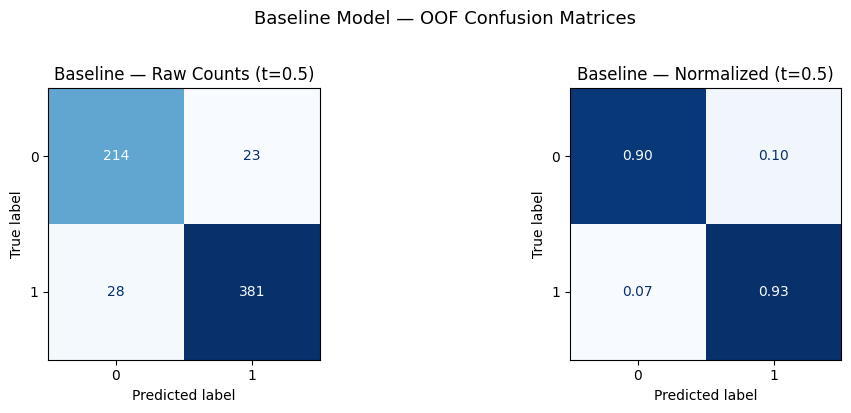

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_oof_confusion_matrix(
    initial_model, X, y, cv,
    threshold=0.5,
    normalize=False,
    title="Baseline — Raw Counts (t=0.5)",
    ax=axes[0]
)

plot_oof_confusion_matrix(
    initial_model, X, y, cv,
    threshold=0.5,
    normalize=True,
    title="Baseline — Normalized (t=0.5)",
    ax=axes[1]
)

plt.suptitle("Baseline Model — OOF Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning
**Purpose:** Search for a better combination of model hyperparameters than the initial defaults. Random forests have multiple knobs that control model complexity and class handling — tuning these can meaningfully improve generalization.

**Search space:**

| Parameter | Values explored | Controls |
|---|---|---|
| `n_estimators` | 200, 500, 1000, 1500 | Number of trees in the forest |
| `max_depth` | 4–9, None | Maximum depth per tree; `None` = unlimited |
| `min_samples_split` | 2, 5, 10, 15 | Minimum samples required to split a node |
| `min_samples_leaf` | 1–6 | Minimum samples required at a leaf node |
| `max_features` | sqrt, log2, 0.3, 0.5 | Number of features considered at each split |
| `class_weight` | balanced, balanced_subsample, None | How class imbalance is handled |

**Why `RandomizedSearchCV` over `GridSearchCV`:** Grid search evaluates every possible combination, which is computationally expensive. Randomized search samples `n_iter=60` combinations randomly, covering a wide range of the parameter space efficiently while finding near-optimal settings in a fraction of the time.

**Optimization target:** `roc_auc` — chosen because it evaluates the model's ranking ability across all thresholds, making it a robust objective that is not sensitive to any single threshold choice.

**`refit=True`:** After finding the best parameters, the model is automatically retrained on the full dataset using those parameters, producing `best_model` ready for evaluation.


In [12]:
parameters = {
    "n_estimators": [200, 500, 1000, 1500],
    "max_depth": [4, 5, 6, 7, 8, 9, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 3, 4, 5, 6],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": ["balanced", "balanced_subsample", None]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = parameters,
    n_iter = 60,
    scoring = "roc_auc",
    cv = cv,
    verbose = 2,
    random_state = 42,
    n_jobs = -1,
    refit = True
)
search.fit(X, y)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

best_model = search.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END class_weight=None, max_depth=8, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=   2.6s
[CV] END class_weight=None, max_depth=8, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=   2.7s
[CV] END class_weight=None, max_depth=8, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=   2.8s
[CV] END class_weight=None, max_depth=8, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=   2.8s
[CV] END class_weight=None, max_depth=8, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=   2.8s
[CV] END class_weight=balanced, max_depth=6, max_features=sqrt, min_samples_leaf=6, min_samples_split=15, n_estimators=200; total time=   0.3s
[CV] END class_weight=balanced, max_depth=6, max_features=sqrt, min_samples_leaf=6, min_samples_split=15,

## 8. Tuned Model Cross Validation
**Purpose:** Re-evaluate model performance after hyperparameter tuning using the same CV strategy and metrics as Step 1. This allows a direct, apples-to-apples comparison between the initial and tuned models.

**Output:** The same train/test/gap table as Step 1, now for the tuned model. Key things to check:

- Did test scores improve over the baseline?
- Did the train-test gap change (more or less overfitting)?
- Are the improvements consistent across folds (low std)?

In [13]:
cv_results_tuned = cross_validate(
    best_model, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print(f"\n{'Metric':20s} {'Train':20s} {'Test':20s} {'Gap'}")
print("-" * 72)
for m in metrics:
    train_mean = cv_results_tuned[f"train_{m}"].mean()
    train_std  = cv_results_tuned[f"train_{m}"].std()
    test_mean  = cv_results_tuned[f"test_{m}"].mean()
    test_std   = cv_results_tuned[f"test_{m}"].std()
    gap        = train_mean - test_mean
    print(
        f"{m:20s} "
        f"{train_mean:.4f} ± {train_std:.4f} {"":5s}"
        f"{test_mean:.4f} ± {test_std:.4f}{"":5s}"
        f"{gap:+.4f}"
    )


Metric               Train                Test                 Gap
------------------------------------------------------------------------
roc_auc              1.0000 ± 0.0000      0.9648 ± 0.0080     +0.0352
f1_macro             0.9967 ± 0.0017      0.9187 ± 0.0193     +0.0780
recall_c1            0.9951 ± 0.0024      0.9364 ± 0.0226     +0.0587
precision_c1         1.0000 ± 0.0000      0.9433 ± 0.0101     +0.0567


### 8.1. Tuned Model Confusion Matrix
**Purpose:** Visualize the tuned model's prediction behavior at the default threshold of `0.5`, using OOF predictions. Comparing this directly against the baseline confusion matrix shows whether hyperparameter tuning improved class-level prediction quality.

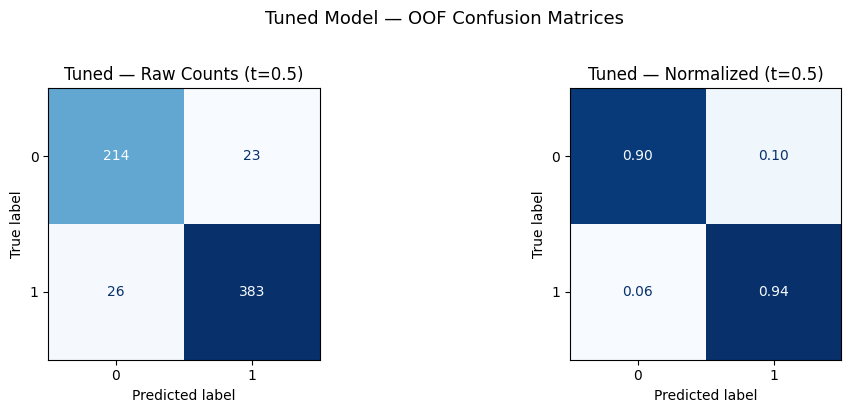

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_oof_confusion_matrix(
    best_model, X, y, cv,
    threshold=0.5,
    normalize=False,
    title="Tuned — Raw Counts (t=0.5)",
    ax=axes[0]
)

plot_oof_confusion_matrix(
    best_model, X, y, cv,
    threshold=0.5,
    normalize=True,
    title="Tuned — Normalized (t=0.5)",
    ax=axes[1]
)

plt.suptitle("Tuned Model — OOF Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Threshold tuning on Best Model

**Purpose:** The default classification threshold of `0.5` is arbitrary. Threshold tuning finds the probability cutoff that best aligns model behavior with the desired performance objective. This is done on OOF probabilities to ensure honest evaluation.

**Why OOF probabilities:** Using `cross_val_predict(method="predict_proba")` ensures that each sample's probability was produced by a model that had never seen that sample during training. Tuning the threshold on training-set probabilities would be overly optimistic.

**Threshold sweep:** Thresholds from `0.20` to `0.70` are evaluated in steps of `0.01`. At each threshold, the following metrics are computed:

| Metric | Description |
|---|---|
| `f1_macro` | Balanced F1 across both classes |
| `f1_class1` | F1 specifically for class 1 |
| `recall_c1` | Fraction of true class 1 cases caught |
| `precision_c1` | Fraction of predicted class 1 cases that are correct |

**Best threshold selection — four objectives:**

| Variable | Objective | Use when |
|---|---|---|
| `best_t_macro` | Maximizes macro F1 | You want balanced performance across both classes |
| `best_t_class1` | Maximizes class 1 F1 | Class 1 is the primary class of interest |
| `best_t_constr` | Highest precision where recall ≥ 0.80 | You need a minimum recall guarantee |
| `best_t_precision_c1` | Maximizes class 1 precision | Minimizing false positives is the priority |

**Threshold comparison plot:** A grid of confusion matrices is plotted across selected thresholds (`0.30`, `0.40`, best precision threshold, best class 1 F1 threshold, `0.50`). Raw counts (top row) and normalized rates (bottom row) are shown side by side, allowing visual inspection of how the precision–recall tradeoff shifts with the threshold.

In [15]:
# Get OOF probabilities for the tuned model
y_prob_oof = cross_val_predict(
    best_model, X, y, cv=cv, method="predict_proba"
)[:, 1]

thresholds = np.arange(0.20, 0.71, 0.01)
thresh_results = []

for t in thresholds:
    y_pred_t = (y_prob_oof >= t).astype(int)

    tp = np.sum((y_pred_t == 1) & (y == 1))
    fp = np.sum((y_pred_t == 1) & (y == 0))
    fn = np.sum((y_pred_t == 0) & (y == 1))

    thresh_results.append({
        "threshold":    round(t, 2),
        "f1_macro":     f1_score(y, y_pred_t, average="macro"),
        "f1_class1":    f1_score(y, y_pred_t, pos_label=1),
        "recall_c1":    tp / (tp + fn + 1e-9),
        "precision_c1": tp / (tp + fp + 1e-9),
    })

thresh_df = pd.DataFrame(thresh_results)

# Find best thresholds under different objectives
best_t_macro  = thresh_df.loc[thresh_df["f1_macro"].idxmax(),  "threshold"]
best_t_class1 = thresh_df.loc[thresh_df["f1_class1"].idxmax(), "threshold"]
best_t_precision_c1 = thresh_df.loc[thresh_df["precision_c1"].idxmax(), "threshold"]

# Constrained: highest precision where recall >= 0.80
high_recall   = thresh_df[thresh_df["recall_c1"] >= 0.80]
best_t_constr = high_recall.loc[high_recall["precision_c1"].idxmax(), "threshold"] \
                if not high_recall.empty else None

print(f"\nBest threshold (macro F1)       : {best_t_macro}")
print(f"Best threshold (class 1 F1)     : {best_t_class1}")
print(f"Best threshold (recall≥0.80)    : {best_t_constr}")
print(f"Best threshold (best precision)    : {best_t_precision_c1}")


Best threshold (macro F1)       : 0.53
Best threshold (class 1 F1)     : 0.53
Best threshold (recall≥0.80)    : 0.68
Best threshold (best precision)    : 0.68


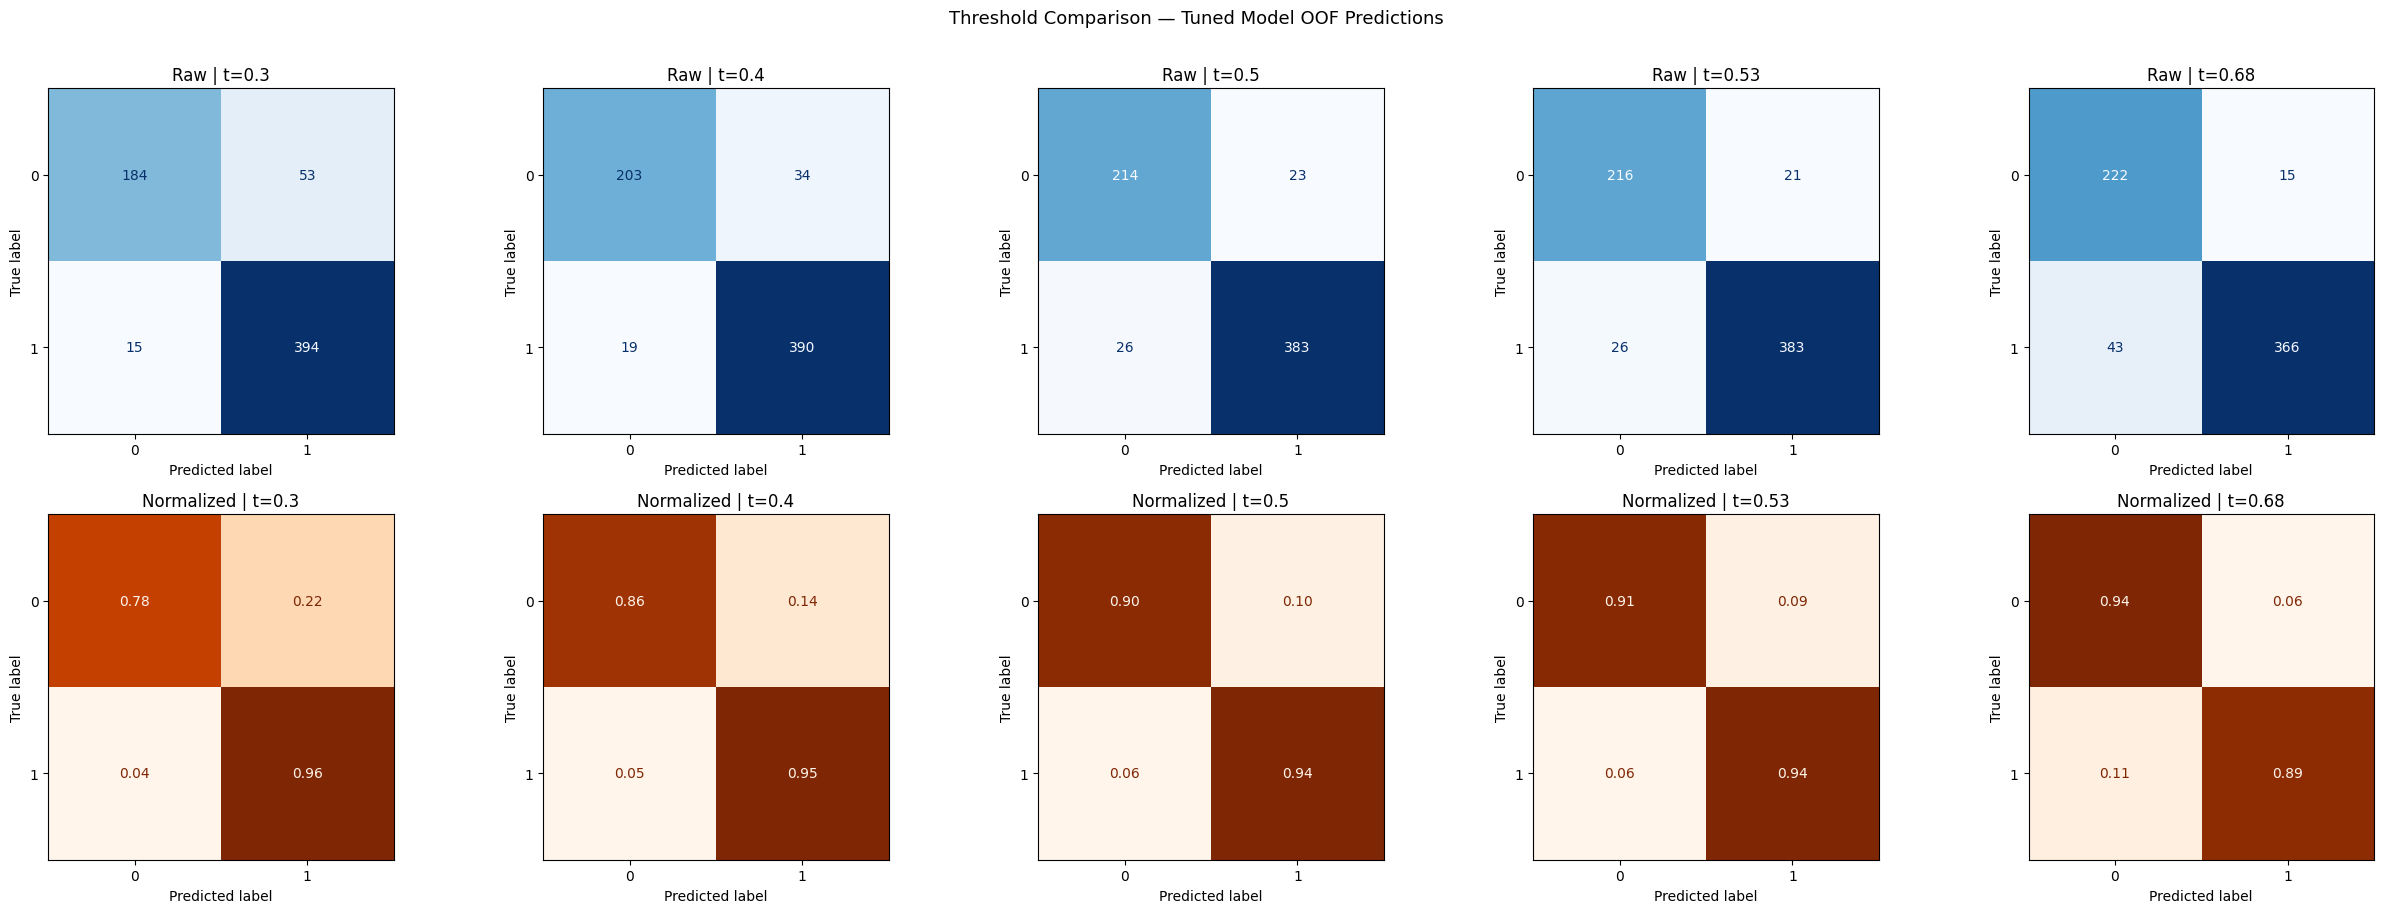

In [16]:
compare_thresholds = [0.30, 0.40, best_t_precision_c1, best_t_class1,  0.50]
compare_thresholds = sorted(set(compare_thresholds))   # deduplicate + sort

fig, axes = plt.subplots(2, len(compare_thresholds), figsize=(5 * len(compare_thresholds), 9))

for i, t in enumerate(compare_thresholds):
    y_pred_t = (y_prob_oof >= t).astype(int)

    # Raw counts (top row)
    cm_raw = confusion_matrix(y, y_pred_t)
    ConfusionMatrixDisplay(cm_raw).plot(
        ax=axes[0][i], cmap="Blues",
        values_format="d", colorbar=False
    )
    axes[0][i].set_title(f"Raw | t={t}")

    # Normalized (bottom row)
    cm_norm = confusion_matrix(y, y_pred_t, normalize="true")
    ConfusionMatrixDisplay(cm_norm).plot(
        ax=axes[1][i], cmap="Oranges",
        values_format=".2f", colorbar=False
    )
    axes[1][i].set_title(f"Normalized | t={t}")

plt.suptitle("Threshold Comparison — Tuned Model OOF Predictions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
chosen_threshold = best_t_macro   # swap to best_t_class1 or best_t_constr as needed
y_pred_final = (y_prob_oof >= chosen_threshold).astype(int)

print(f"\nChosen threshold : {chosen_threshold}")
print(classification_report(y, y_pred_final))
print(f"ROC-AUC          : {roc_auc_score(y, y_prob_oof):.4f}")


Chosen threshold : 0.53
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90       237
         1.0       0.95      0.94      0.94       409

    accuracy                           0.93       646
   macro avg       0.92      0.92      0.92       646
weighted avg       0.93      0.93      0.93       646

ROC-AUC          : 0.9632


## 10. Summary

**Chosen threshold:** `best_t_macro` by default. This can be swapped to `best_t_class1` or `best_t_constr` depending on the operational requirement.

**Output:**
- Full `classification_report` showing precision, recall, F1, and support per class
- Overall accuracy and weighted/macro averages
- `ROC-AUC` as a threshold-independent measure of overall discriminative ability

> **Note for deployment:** The chosen threshold is part of the model's business logic and must be saved and applied consistently in production. The ONNX model will output raw probabilities — the threshold must be enforced in the scoring layer (e.g., Azure Function) rather than relying on the default `0.5`.